In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/home/adrinospy/Desktop/Programming/mathsNotes/data/extracted_images'):
    for filename in filenames:
        os.path.join(dirname, filename)

In [1]:
import numpy as np
import cv2
import os
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, Activation, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.initializers import glorot_uniform
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import LearningRateScheduler, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import seaborn as sn
import matplotlib.pyplot as plt
import pandas as pd
import imutils
from imutils.contours import sort_contours

2025-05-09 13:20:32.045793: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746777032.076009  184963 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746777032.084250  184963 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746777032.106666  184963 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1746777032.106695  184963 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1746777032.106697  184963 computation_placer.cc:177] computation placer alr

In [ ]:
!pip install imutils


In [5]:
!wget https://cainvas-static.s3.amazonaws.com/media/user_data/Yuvnish17/data.zip
!unzip -qo data.zip

--2025-02-11 02:02:40--  https://cainvas-static.s3.amazonaws.com/media/user_data/Yuvnish17/data.zip
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving cainvas-static.s3.amazonaws.com (cainvas-static.s3.amazonaws.com)... 16.12.40.107, 16.12.40.119, 52.219.158.119, ...
Connecting to cainvas-static.s3.amazonaws.com (cainvas-static.s3.amazonaws.com)|16.12.40.107|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28437489 (27M) [application/x-zip-compressed]
Saving to: ‘data.zip.1’

data.zip.1          100%[===================>]  27.12M  22.8MB/s    in 1.2s    

2025-02-11 02:02:41 (22.8 MB/s) - ‘data.zip.1’ saved [28437489/28437489]



In [2]:
x = []
y = []
datadir = '/home/adrinospy/Desktop/Programming/mathsNotes/data/extracted_images'
for folder in os.listdir(datadir):
    path = os.path.join(datadir, folder)
    for images in os.listdir(path):
        img = cv2.imread(os.path.join(path, images))
        x.append(img)
        y.append(folder)

print(len(x))
print(len(y))
print(f'labels : {list(set(y))}')

272339
272339
labels : ['1', '2', ')', 'pi', '8', '0', 'forward_slash', '4', 'times', '(', '7', '=', '-', '6', 'log', 'sqrt', 'lim', 'y', 'sin', 'theta', '+', '5', 'z', 'X', '9', 'infty', 'cos', 'tan', '3', 'int']


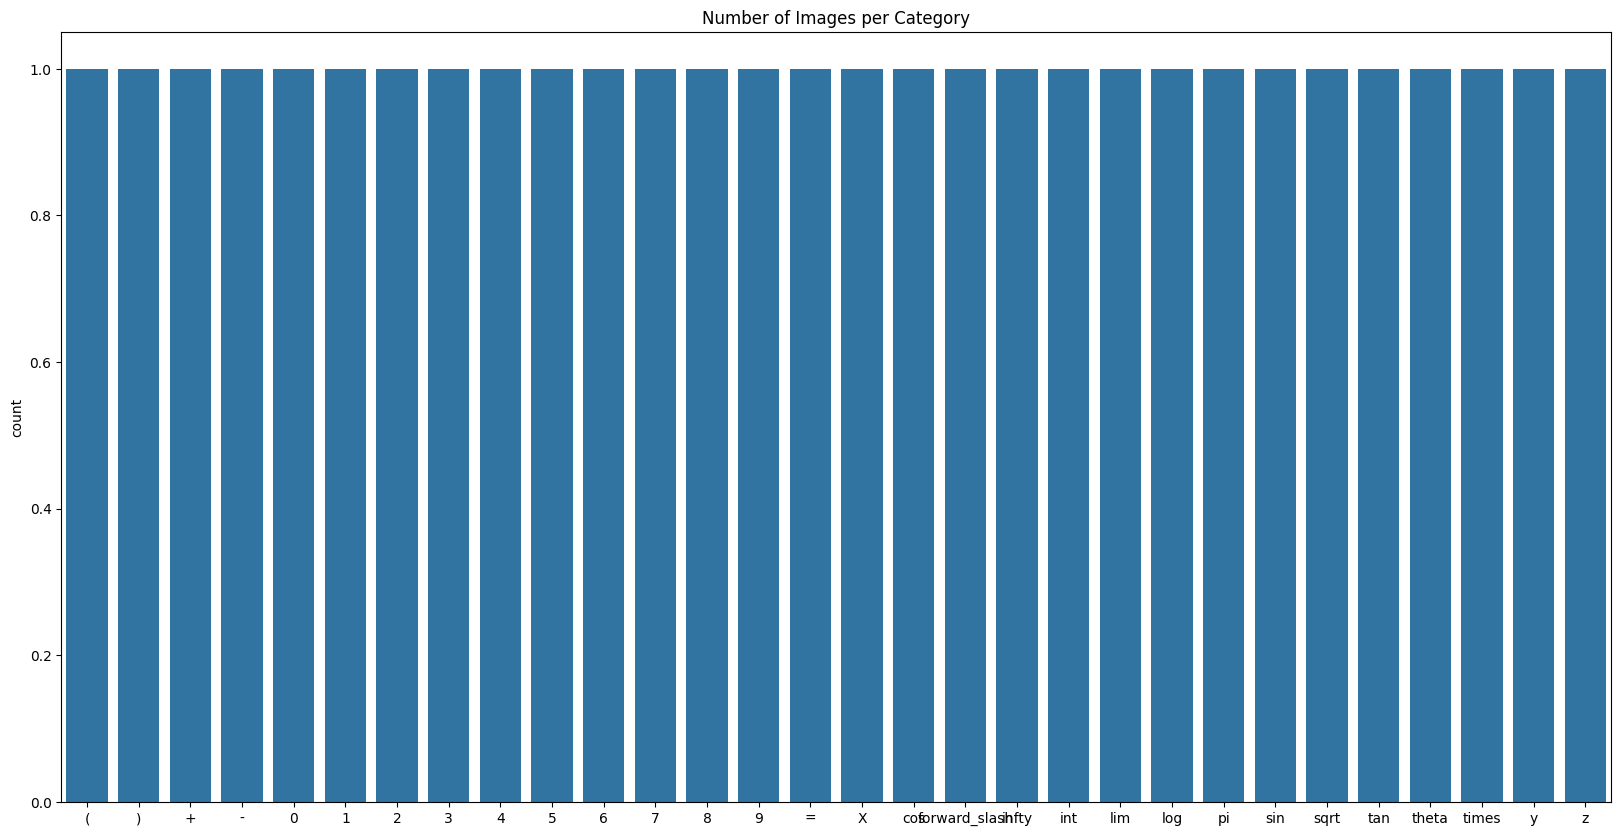

In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

unique, count = np.unique(y, return_counts=True)
figure = plt.figure(figsize=(20, 10))
sns.countplot(x=unique)
plt.title('Number of Images per Category')
plt.show()

In [4]:
X = []
for i in range(len(x)):
#     print(i)
    img = x[i]
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    threshold_image = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY_INV|cv2.THRESH_OTSU)[1]
    threshold_image = cv2.resize(threshold_image, (48, 48))
    X.append(threshold_image)
print(len(X))


272339


In [5]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
print(len(y))

272339


In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.1)

In [7]:
print(len(X_train), len(X_test), len(Y_train), len(Y_test))

245105 27234 245105 27234


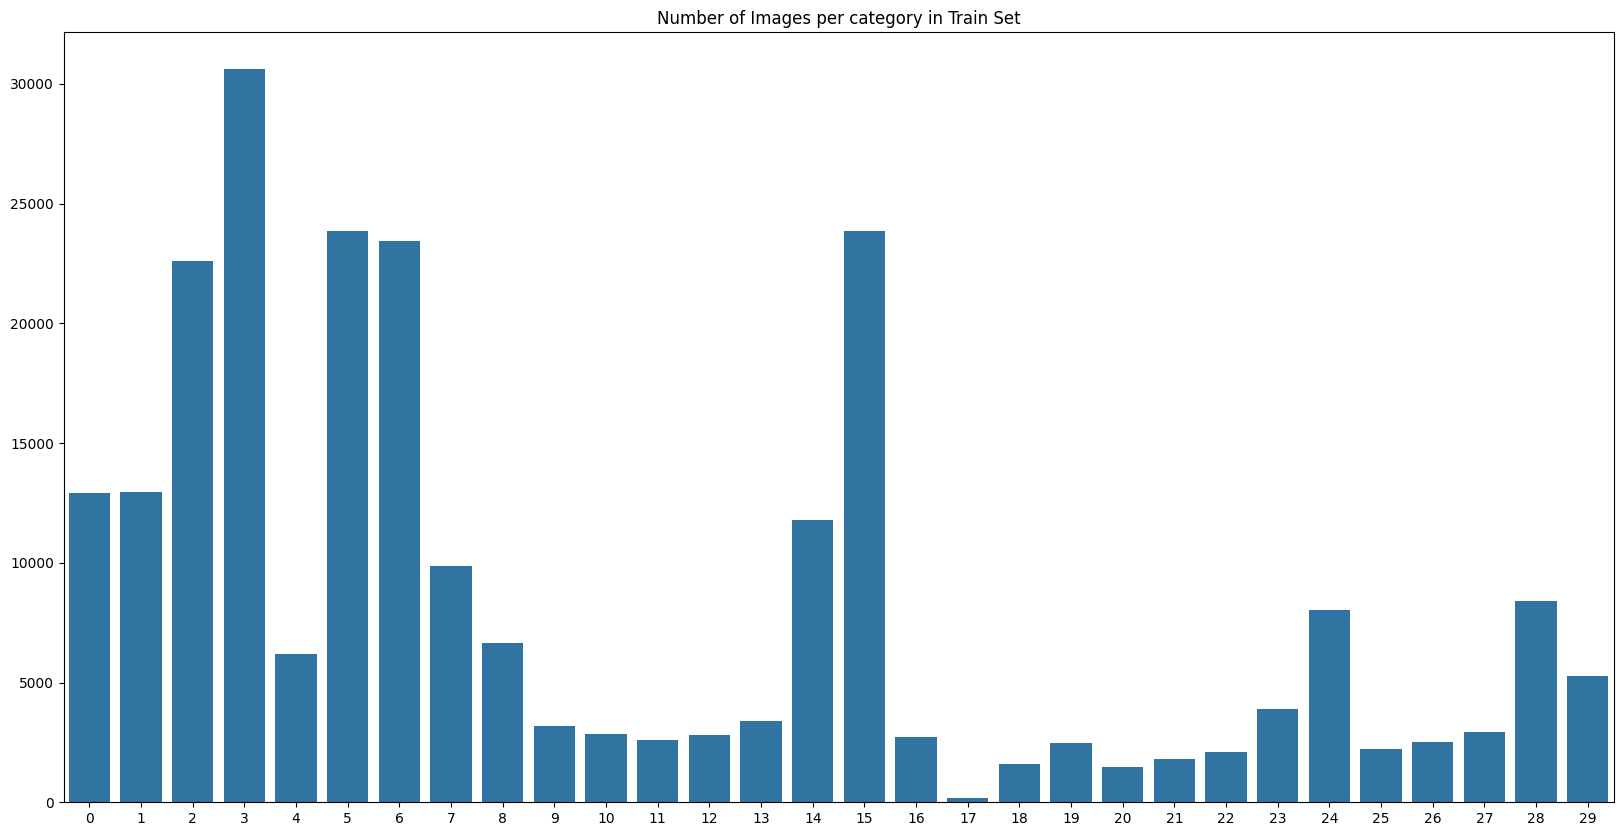

In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

unique_train, count_train = np.unique(Y_train, return_counts=True)
figure = plt.figure(figsize=(20, 10))
ax = sns.barplot(x=unique_train, y=count_train)
ax.set_title('Number of Images per category in Train Set')
plt.show()

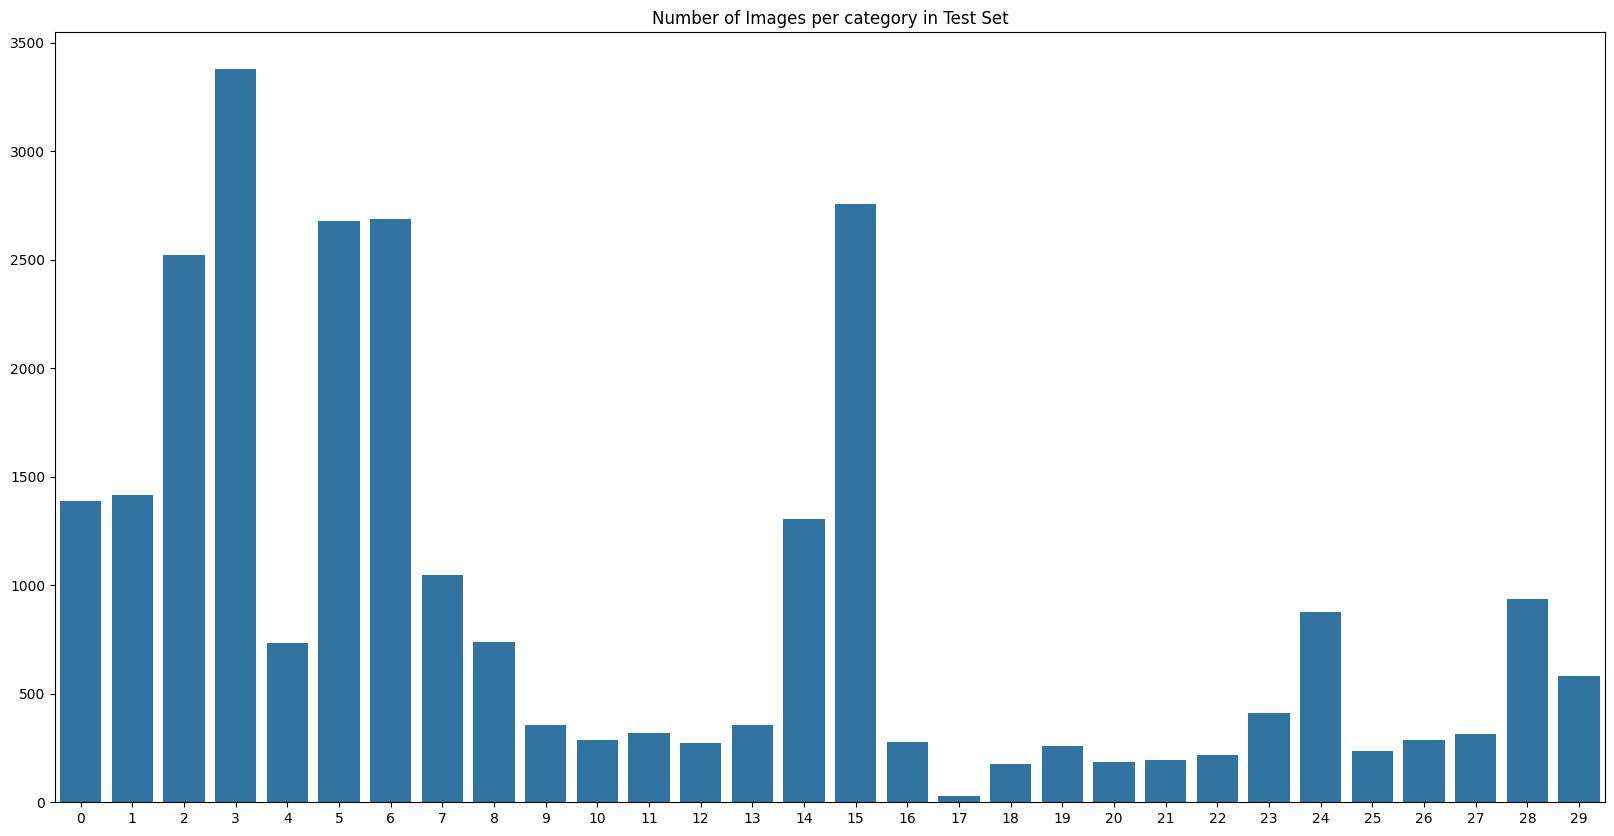

In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

unique_test, count_test = np.unique(Y_test, return_counts=True)
figure = plt.figure(figsize=(20, 10))
ax = sns.barplot(x=unique_test, y=count_test)
ax.set_title('Number of Images per category in Test Set')
plt.show()

In [10]:
X_train = np.array(X_train)
X_test = np.array(X_test)
Y_train = np.array(Y_train)
Y_test = np.array(Y_test)

Y_train = to_categorical(Y_train)
Y_test = to_categorical(Y_test)
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)
X_train = X_train/255.
X_test = X_test/255.

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(245105, 48, 48, 1)
(27234, 48, 48, 1)
(245105, 30)
(27234, 30)


In [11]:
def math_symbol_and_digits_recognition(input_shape=(48, 48, 1)):
    regularizer = l2(0.01)
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(Conv2D(64, (3, 3), strides=(1, 1), padding='same', 
                     kernel_initializer=glorot_uniform(seed=0), 
                     name='conv1', activity_regularizer=regularizer))
    model.add(Activation(activation='relu', name='act1'))
    model.add(MaxPool2D((2, 2), strides=(2, 2)))
    model.add(Conv2D(128, (3, 3), strides=(1, 1), padding='same', 
                     kernel_initializer=glorot_uniform(seed=0), 
                     name='conv2', activity_regularizer=regularizer))
    model.add(Activation(activation='relu', name='act2'))
    model.add(MaxPool2D((2, 2), strides=(2, 2)))
    model.add(Conv2D(256, (3, 3), strides=(1, 1), padding='same', 
                     kernel_initializer=glorot_uniform(seed=0), 
                     name='conv3', activity_regularizer=regularizer))
    model.add(Activation(activation='relu', name='act3'))
    model.add(MaxPool2D((2, 2), strides=(2, 2)))
    model.add(Conv2D(128, (3, 3), strides=(1, 1), padding='same', 
                     kernel_initializer=glorot_uniform(seed=0), 
                     name='conv4', activity_regularizer=regularizer))
    model.add(Activation(activation='relu', name='act4'))
    model.add(MaxPool2D((2, 2), strides=(2, 2)))
    model.add(Flatten())
    model.add(Dropout(0.5))
    model.add(Dense(128, activation='relu', kernel_initializer=glorot_uniform(seed=0), name='fc1'))
    model.add(Dense(128, activation='relu', kernel_initializer=glorot_uniform(seed=0), name='fc2'))
    model.add(Dense(30, activation='softmax', kernel_initializer=glorot_uniform(seed=0), name='fc3'))
    
    optimizer = Adam()
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

In [12]:
model = math_symbol_and_digits_recognition(input_shape=(48, 48, 1))
model.summary()

I0000 00:00:1746777094.965924  184963 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2610 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act1 (Activation)               │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act2 (Activation)               │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act3 (Activation)               │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 6, 6, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act4 (Activation)               │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 30)             │         3,870 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 832,670 (3.18 MB)

 Trainable params: 832,670 (3.18 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
def step_decay(epoch):
    initial_learning_rate = 0.001
    dropEvery = 10
    factor = 0.5
    lr = initial_learning_rate*(factor**np.floor((1 + epoch)/dropEvery))
    return float(lr)

checkpoint = ModelCheckpoint('ocr_latest.h5', 
                             monitor='val_loss', save_best_only=True, 
                             verbose=1, mode='min')

callbacks = [checkpoint, LearningRateScheduler(step_decay)]

In [14]:
aug = ImageDataGenerator(zoom_range=0.2,
                         rotation_range=10,
                         width_shift_range=0.2,
                         height_shift_range=0.2,
                         fill_mode='nearest')
hist = model.fit(aug.flow(X_train, Y_train, batch_size=8), batch_size=8, epochs=40, validation_data=(X_test, Y_test))
# hist2 = model2.fit(X_train, Y_train, batch_size=128, epochs=100, validation_data=(X_test, Y_test), callbacks=callbacks)

Epoch 1/40


/home/adrinospy/Desktop/Programming/mathsNotes/myenv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1746777102.515944  185224 service.cc:152] XLA service 0x7453ac00e530 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746777102.516252  185224 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2025-05-09 13:21:42.857166: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1746777103.404497  185224 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-05-09 13:21:44

   20/30639 ━━━━━━━━━━━━━━━━━━━━ 4:18 8ms/step - accuracy: 0.1097 - loss: 9.9208     

I0000 00:00:1746777108.123408  185224 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 3296/30639 ━━━━━━━━━━━━━━━━━━━━ 2:33 6ms/step - accuracy: 0.3250 - loss: 2.7977

2025-05-09 13:22:07.101061: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.13 = (f32[1,128,24,24]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,64,24,24]{3,2,1,0} %bitcast.6650, f32[128,64,3,3]{3,2,1,0} %bitcast.5771, f32[128]{0} %bitcast.6710), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_1/conv2_1/convolution" source_file="/home/adrinospy/Desktop/Programming/mathsNotes/myenv/lib/python3.12/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-05-09 13:22:07.161243: I external/local_xla/xla/service/gpu/autotuning/conv_algori

30636/30639 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6585 - loss: 1.5421

2025-05-09 13:24:39.707575: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 250988544 exceeds 10% of free system memory.
2025-05-09 13:24:39.889333: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 250988544 exceeds 10% of free system memory.
2025-05-09 13:24:47.516783: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.13 = (f32[2,128,24,24]{3,2,1,0}, u8[0]{0}) custom-call(f32[2,64,24,24]{3,2,1,0} %bitcast.762, f32[128,64,3,3]{3,2,1,0} %bitcast.769, f32[128]{0} %bitcast.771), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_1/conv2_1/convolution" source_file="/home/adrinospy/Desktop/Programming/mathsNotes/myenv/lib/python3.12/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_c

30639/30639 ━━━━━━━━━━━━━━━━━━━━ 187s 6ms/step - accuracy: 0.6585 - loss: 1.5420 - val_accuracy: 0.9412 - val_loss: 0.8072
Epoch 2/40
30639/30639 ━━━━━━━━━━━━━━━━━━━━ 176s 6ms/step - accuracy: 0.8400 - loss: 0.9979 - val_accuracy: 0.9191 - val_loss: 0.7398
Epoch 3/40
30639/30639 ━━━━━━━━━━━━━━━━━━━━ 177s 6ms/step - accuracy: 0.8542 - loss: 0.9920 - val_accuracy: 0.9364 - val_loss: 0.7449
Epoch 4/40
30639/30639 ━━━━━━━━━━━━━━━━━━━━ 178s 6ms/step - accuracy: 0.8568 - loss: 1.0047 - val_accuracy: 0.9376 - val_loss: 0.6583
Epoch 5/40
30639/30639 ━━━━━━━━━━━━━━━━━━━━ 180s 6ms/step - accuracy: 0.8604 - loss: 1.0198 - val_accuracy: 0.9418 - val_loss: 0.8104
Epoch 6/40
30639/30639 ━━━━━━━━━━━━━━━━━━━━ 181s 6ms/step - accuracy: 0.8603 - loss: 1.0478 - val_accuracy: 0.9255 - val_loss: 0.8380
Epoch 7/40
30639/30639 ━━━━━━━━━━━━━━━━━━━━ 182s 6ms/step - accuracy: 0.8615 - loss: 1.0596 - val_accuracy: 0.9435 - val_loss: 1.1101
Epoch 8/40
30639/30639 ━━━━━━━━━━━━━━━━━━━━ 183s 6ms/step - accuracy: 0.8

In [15]:
model.save('ocr_latest_124.h5')

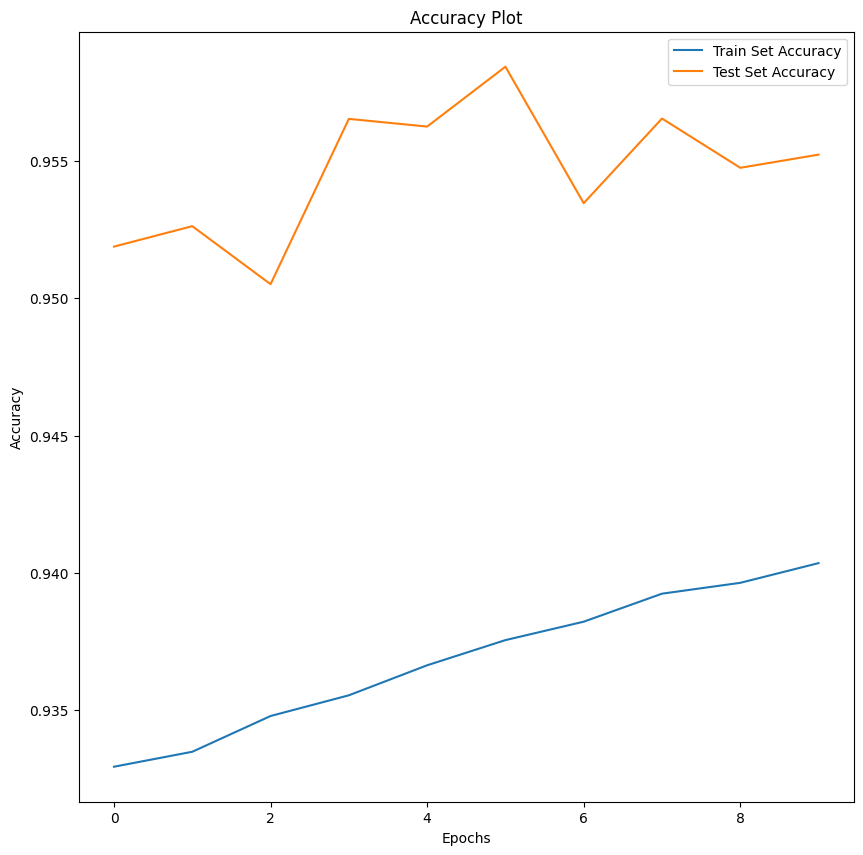

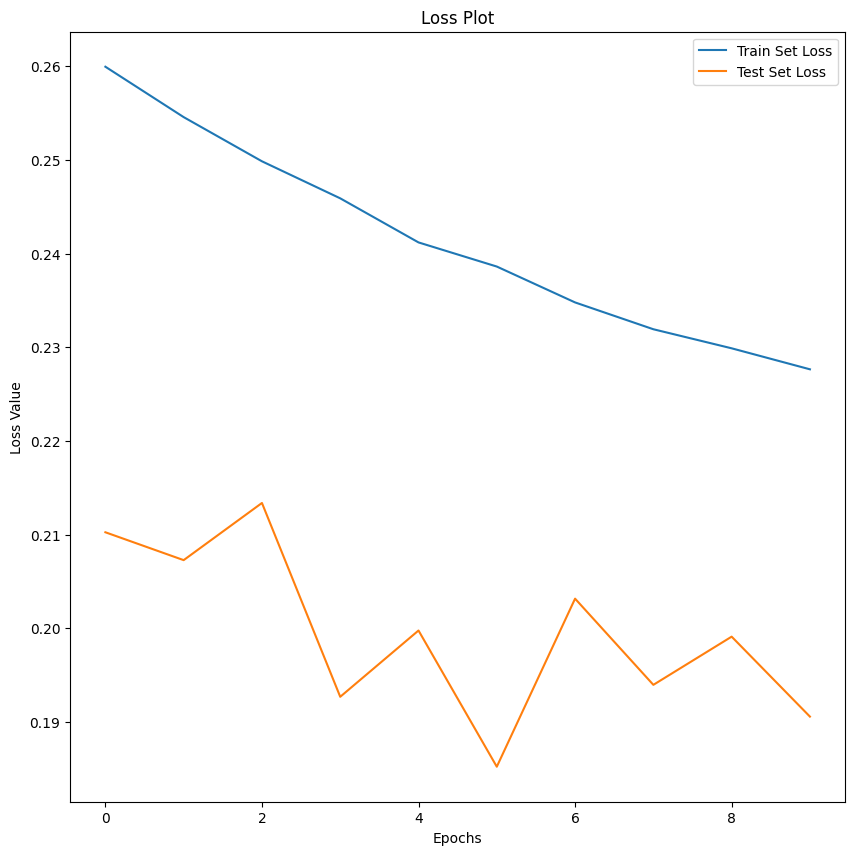

In [27]:
figure = plt.figure(figsize=(10, 10))
plt.plot(hist.history['accuracy'], label='Train Set Accuracy')
plt.plot(hist.history['val_accuracy'], label='Test Set Accuracy')
plt.title('Accuracy Plot')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='upper right')
plt.show()

figure2 = plt.figure(figsize=(10, 10))
plt.plot(hist.history['loss'], label='Train Set Loss')
plt.plot(hist.history['val_loss'], label='Test Set Loss')
plt.title('Loss Plot')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend(loc='upper right')
plt.show()

In [9]:
ypred = model.predict(X_test)
ypred = np.argmax(ypred, axis=1)
Y_test_hat = np.argmax(Y_test, axis=1)
print(classification_report(Y_test_hat, ypred))

NameError: name 'model' is not defined

In [1]:
import numpy as np
import tensorflow as tf
from PIL import Image, ImageOps

# Load the saved model (make sure your model.h5 file is in the working directory)
model = tf.keras.models.load_model('ocr_latest.h5')


2025-05-10 03:26:54.980398: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746827815.049118    3828 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746827815.067635    3828 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746827815.210297    3828 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1746827815.210337    3828 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1746827815.210340    3828 computation_placer.cc:177] computation placer alr

In [2]:
img_path = '/home/adrinospy/Desktop/Programming/mathsNotes/out/0405148ac6639b60.png'

# Open the image using PIL, convert it to grayscale ('L') and resize to 32x32
img = Image.open(img_path).convert('L')  # 'L' mode means grayscale
# img = ImageOps.invert(img)
img = img.resize((48, 48))
img = ImageOps.invert(img)

# Convert the image to a numpy array and normalize pixel values to [0, 1]
img_array = np.array(img).astype('float32') / 255.0

# Reshape the image to add the channel and batch dimensions: (1, 32, 32, 1)
img_array = np.expand_dims(img_array, axis=-1)  # from (32,32) to (32,32,1)
img_array = np.expand_dims(img_array, axis=0)    # from (32,32,1) to (1,32,32,1)

# Use the model to predict on the preprocessed image
predictions = model.predict(img_array)
# If the output is class probabilities, get the class with highest probability
predicted_class = np.argmax(predictions, axis=1)

print("Predictions:", predictions)
print("Predicted class:", predicted_class)
labels = ['(',')','+','-','0','1','2','3','4','5','6','7','8','9','=','x','cos','/','infi','int','lim','log','pi','sin','sqrt','tan','theta','times','y','z']
print(labels[predicted_class[0]])

I0000 00:00:1746827832.406922    4114 service.cc:152] XLA service 0x7f9938006c40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746827832.406937    4114 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2025-05-10 03:27:12.423923: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1746827832.501769    4114 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-05-10 03:27:12.994163: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.13 = (f32[1,128,24,24]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,64,24,24]{3,2,1,0} %bitcast.296, f32[128,64,3,3]{3,2,1,0} %bitcast.303, f32[128]{0} %bitcast.305), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predictions: [[3.2413754e-01 4.4210181e-03 4.5428521e-04 2.2285315e-01 1.1617994e-03
  2.9885146e-01 7.2337789e-03 1.1786374e-03 1.8426022e-04 2.5029175e-04
  5.0961343e-04 3.3081281e-03 3.7030692e-05 6.8775116e-05 7.0263945e-02
  1.4807560e-03 9.3942667e-09 5.7005327e-02 1.5858203e-06 1.0692979e-03
  4.6342825e-07 1.1164429e-10 2.8609807e-05 4.6666004e-09 4.7216838e-04
  9.6520077e-11 7.0824035e-06 1.1032399e-03 2.5307070e-03 1.3868604e-03]]
Predicted class: [0]
(


I0000 00:00:1746827833.684161    4114 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


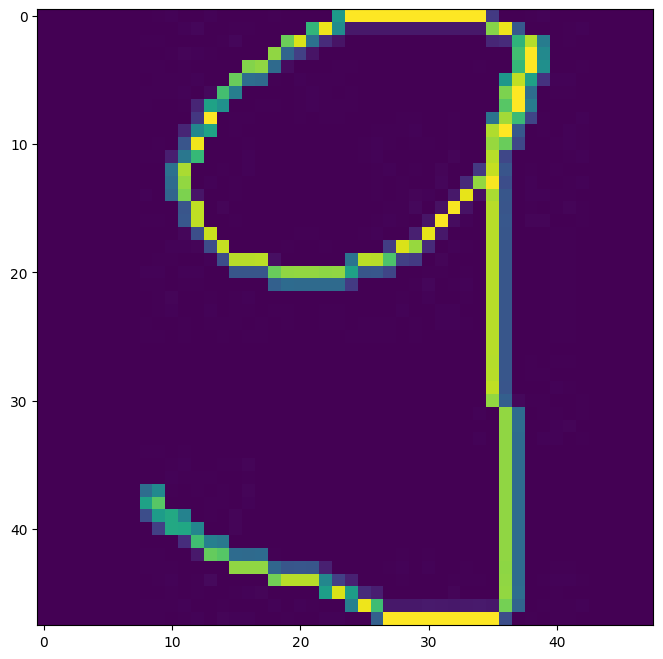

In [ ]:
import matplotlib.pyplot as plt
import cv2
figure = plt.figure(figsize=(8, 8))
# img = cv2.resize(img, (64, 64))
plt.imshow(img)

In [12]:
model = tf.keras.models.load_model('ocr_large_48_2.h5')

I0000 00:00:1746734902.319344    3832 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2610 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5
